In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
import joblib                                       # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                             # 텐서플로우 lib


from tensorflow.keras import layers, models

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential                   
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'          # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False             # 마이너스 부호 깨짐 방지


np.random.seed(42)
tf.random.set_seed(42)

In [35]:
## 데이터 가져오기  (32x32 이미지 크기 ) 
# fashion mnist 데이터 가져오기
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 클래스 네임정의 
# 클래스 이름정의 
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

print('X_train shape: ', X_train.shape)    
print('X_test shape: ', X_test.shape)

# CNN 입력 형태에 맞게 채널 차원을 reshape
# y_train = y_train.reshape(-1) #shape(30000,1) --> (30000)
# y_test = y_test.reshape(-1)   #shape(10000,1) --> (10000)


X_train shape:  (50000, 32, 32, 3)
X_test shape:  (10000, 32, 32, 3)


In [36]:
y_train.shape

(50000, 1)

In [37]:
## 픽셀값 0~1 범위로 정규화  TO-DO
X_train = X_train / 255.0
X_test = X_test / 255.0

In [38]:
## 모델정의 <-- cnn layer 3개층 구성 + 출력층 으로 구성 

model = Sequential()    # 순차형 신경망 생성


# 첫 번째 CNN 층
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# 두 번째 CNN 층
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# 세 번째 CNN 층
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# 1차원으로 펼치기
model.add(Flatten())

# 완전 연결층
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# 출력층 - CIFAR10 클래스 10개
model.add(Dense(10, activation='softmax'))



In [39]:
##  모델 컴파일

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 학습 종료 설정 
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [40]:
#========================================
# 5. 모델 학습 
#========================================
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    #callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3749 - loss: 1.6928 - val_accuracy: 0.5278 - val_loss: 1.3299
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5350 - loss: 1.2959 - val_accuracy: 0.5933 - val_loss: 1.1508
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5938 - loss: 1.1509 - val_accuracy: 0.6298 - val_loss: 1.0585
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6335 - loss: 1.0356 - val_accuracy: 0.6468 - val_loss: 1.0046
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6614 - loss: 0.9617 - val_accuracy: 0.6733 - val_loss: 0.9391
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6876 - loss: 0.8846 - val_accuracy: 0.6876 - val_loss: 0.9128
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7091 - loss: 0.8289 - val_accuracy: 0.6898 - val_loss: 0.9126
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7286 - loss: 0.7713 - 

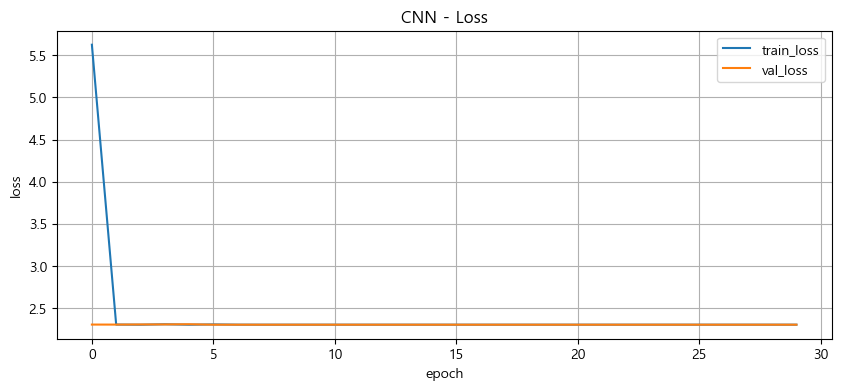

In [31]:
## 결과 시각화 
# 학습 손실 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('CNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

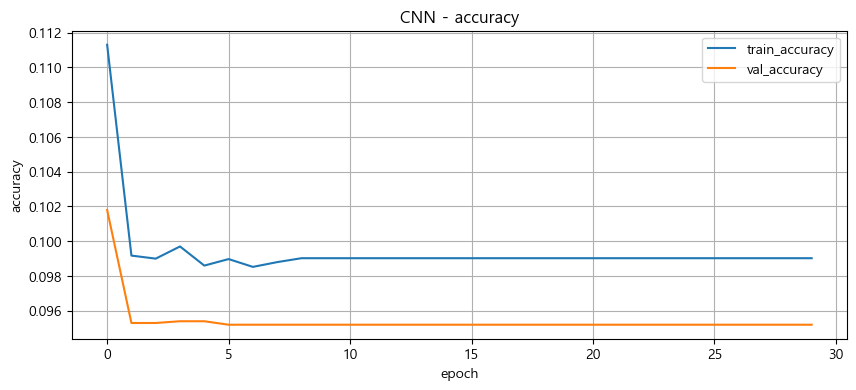

In [32]:
# 학습 정확도 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('CNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [25]:
## 예측 확률 계산

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


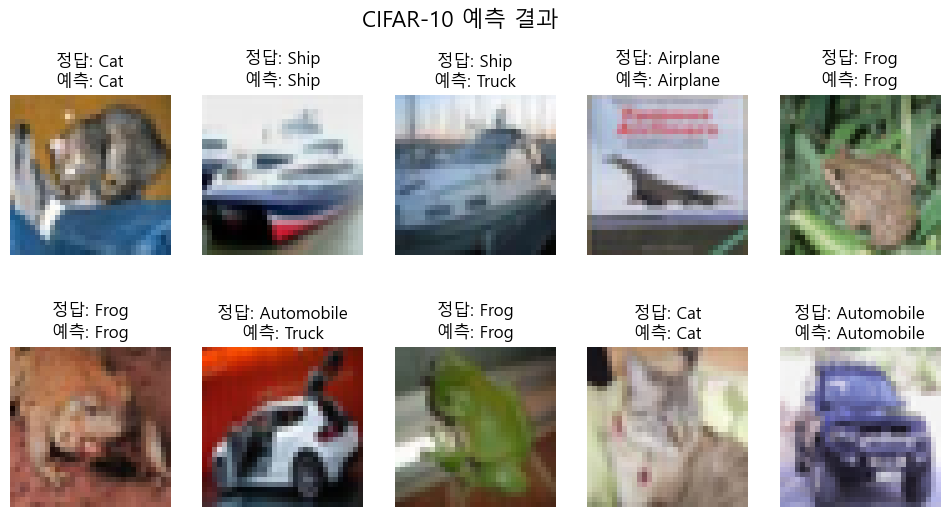

In [33]:
## 10개 이미지 예측 시각화
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])                               
    plt.title(f"정답: {class_names[y_test[i]]}\n예측: {class_names[y_pred[i]]}")
    plt.axis("off")
plt.suptitle("CIFAR-10 예측 결과", fontsize=16)
plt.show()